In [1]:
import pandas
import pm4py
import os
import statistics as st

In [2]:
path='../Output/div/'
csv_files = [pos_csv for pos_csv in os.listdir(path)]

log_df = pandas.DataFrame()
for index, csv in enumerate(csv_files):
    with open(os.path.join(path, csv)) as csv_file:
        case_dataframe = pandas.read_csv(csv_file)
        log_df = pandas.concat([log_df,case_dataframe])

log_df = pm4py.format_dataframe(log_df, case_id='CaseId', activity_key='Activity', timestamp_key='Timestamp')
log = pm4py.convert_to_event_log(log_df)

In [3]:
log_df['CaseId'].nunique()


71

In [4]:
log_df.shape

(2361, 9)

In [5]:
log_df.head()

,CaseId,Timestamp,Activity,Amount,case:concept:name,concept:name,time:timestamp,@@index,@@case_index
0,item_0_0,2025-05-21 18:14:12+00:00,Place Order,1494,item_0_0,Place Order,2025-05-21 18:14:12+00:00,0,0
1,item_0_0,2025-05-24 02:46:12+00:00,Send Invoice,1494,item_0_0,Send Invoice,2025-05-24 02:46:12+00:00,1,0
2,item_0_0,2025-05-26 08:24:12+00:00,Check Availability,1494,item_0_0,Check Availability,2025-05-26 08:24:12+00:00,2,0
3,item_0_0,2025-05-27 08:13:12+00:00,Split Item,1494,item_0_0,Split Item,2025-05-27 08:13:12+00:00,3,0
4,item_0_0,2025-05-27 09:54:12+00:00,Pick Item,420,item_0_0,Pick Item,2025-05-27 09:54:12+00:00,4,0


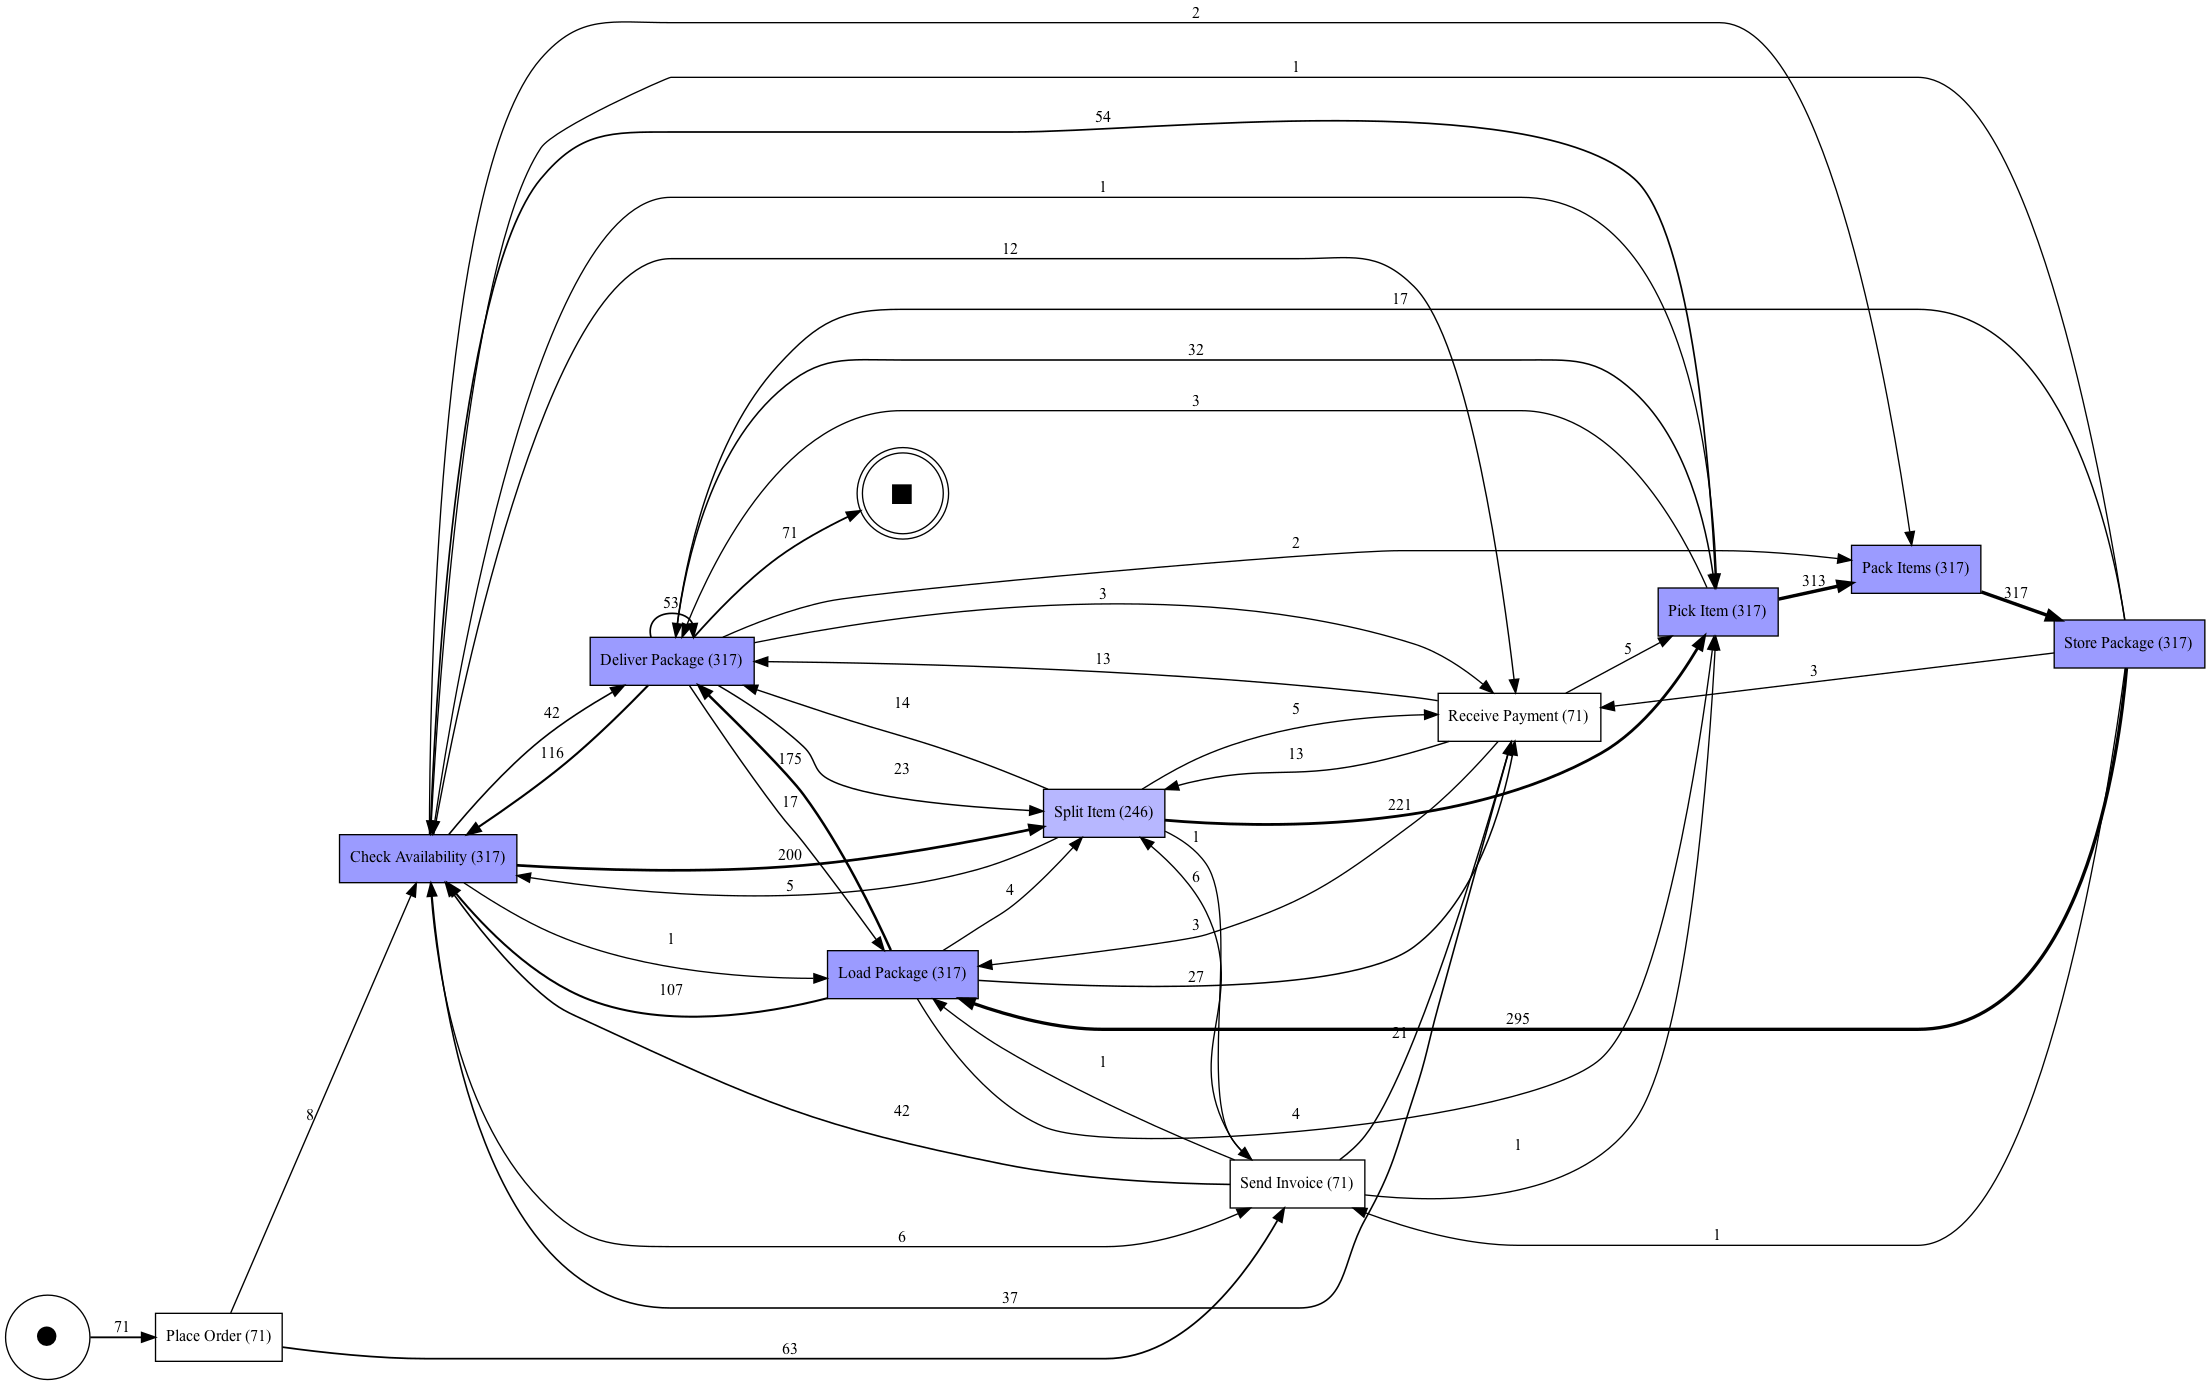

In [6]:
dfg, start, end = pm4py.discover_dfg(log)
pm4py.vis.view_dfg(dfg, start, end)

In [7]:
lead_times = []
for case_id in log_df["CaseId"].unique():
    start = log_df[(log_df["CaseId"]== case_id) & (log_df["Activity"]=="Place Order")]["Timestamp"].min()
    end = log_df[(log_df["CaseId"]== case_id) & (log_df["Activity"]=="Deliver Package")]["Timestamp"].max()
    lead_times.append((end - start).days)
mean_lead_time = st.mean(lead_times)

In [8]:
mean_lead_time

26.056338028169016

In [9]:
partial_lead_times = []
for case_id in log_df["CaseId"].unique():
    start = log_df[(log_df["CaseId"]== case_id) & (log_df["Activity"]=="Place Order")]["Timestamp"].min()
    for _,end in log_df[(log_df["CaseId"]== case_id) & (log_df["Activity"]=="Deliver Package")].iterrows():
        partial_lead_times.append((end["Timestamp"]-start).days)
    
partial_mean_lead_time = st.mean(partial_lead_times)

In [10]:
partial_mean_lead_time

18.514195583596216